# Time Series Coursework
# CID: 01854554

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.linalg import solve_toeplitz

## Question 1


### (a)


The AR(4) process can be defined by the following equation:

$$ X_t = \phi_1 X_{t-1} + \phi_2 X_{t-2} + \phi_3 X_{t-3} + \phi_4 X_{t-4} + \varepsilon_t $$

where $\varepsilon_t$ is white noise with variance $\sigma_{\varepsilon}^2$.

The characteristic polynomial associated with this AR process is:

$$ 1 - \phi_1 z - \phi_2 z^2 - \phi_3 z^3 - \phi_4 z^4 = 0 $$

To have cyclical behavior, we would typically set two pairs of complex conjugate roots for this polynomial, which represent the frequencies and dampening factors of the cycles. The roots are calculated as:

$$
z_1 = r_1 e^{i\theta_1} \; \text{,} \;
z_2 = r_1 e^{-i\theta_1} \; \text{,} \;
z_3 = r_2 e^{i\theta_2} \; \text{,} \;
z_4 = r_2 e^{-i\theta_2}
$$

where $\theta_1 = 2 \pi f_1$, $\theta_2 = 2 \pi f_2$.

We start by expanding the polynomial

$$ (z - z_1) (z - z_2) (z - z_3) (z - z_4) = z^4 + \alpha_3 z^3 + \alpha_2 z^2 + \alpha_1 z + \alpha_0 $$

where

$$
\begin{aligned}
\alpha_0 &= z_1 z_2 z_3 z_4 
= r_1^2 r_2^2 
\\
\alpha_1 &= -(z_1 z_2 z_3 + z_1 z_2 z_4 + z_1 z_3 z_4 + z_2 z_3 z_4) 
= -2 r_1^2 r_2 \cos(\theta_2) - 2 r_1 r_2^2 \cos(\theta_1) 
\\
\alpha_2 &= z_1 z_2 + z_1 z_3 + z_1 z_4 + z_2 z_3 + z_2 z_4 + z_3 z_4
= r_1^2 + r_2^2 + 4 r_1 r_2 \cos(\theta_1) \cos(\theta_2) 
\\
\alpha_3 &= -(z_1 + z_2 + z_3 + z_4)
= -2 r_1 \cos(\theta_1) - 2 r_2 \cos(\theta_2)
\end{aligned}
$$

and noticing that

$$ (z - z_1) (z - z_2) (z - z_3) (z - z_4) = \frac{-1}{\phi_4} (1 - \phi_1 z - \phi_2 z^2 - \phi_3 z^3 - \phi_4 z^4) $$

which gives us the following equations

$$
\alpha_3 = \frac{\phi_3}{\phi_4} \; \text{,} \;
\alpha_2 = \frac{\phi_2}{\phi_4} \; \text{,} \;
\alpha_1 = \frac{\phi_1}{\phi_4} \; \text{,} \;
\alpha_0 = \frac{-1}{\phi_4}
$$

Then we can calculate the roots

$$
\phi_4 = \frac{-1}{\alpha_0} \; \text{,} \;
\phi_3 = \frac{-1}{\alpha_0} \alpha_3 \; \text{,} \;
\phi_2 = \frac{-1}{\alpha_0} \alpha_2 \; \text{,} \;
\phi_1 = \frac{-1}{\alpha_0} \alpha_1
$$


In [2]:
def compute_ar4_coeffs(f1, f2, r1, r2):
    """
    Computes the AR4 coefficients for the given frequencies and radii.

    Parameters
    ----------
    :param f1, f2 (float):
      The frequencies that control the cyclical behavior.
    :param r1, r2 (float):
      The radii that control the strength of the cyclical behaviors
    """

    # Convert frequencies to radians
    theta1 = 2 * np.pi * f1
    theta2 = 2 * np.pi * f2

    # Invert the radii
    r1 = 1 / r1
    r2 = 1 / r2

    # Compute the polynomial coefficients using the previous formulas
    coeffs = np.array(
        [
            r1**2 * r2**2,
            -2 * r1**2 * r2 * np.cos(theta2) - 2 * r1 * r2**2 * np.cos(theta1),
            r1**2 + r2**2 + 4 * r1 * r2 * np.cos(theta1) * np.cos(theta2),
            -2 * r1 * np.cos(theta1) - 2 * r2 * np.cos(theta2),
            1,
        ]
    )
    # Make the constant term 1
    coeffs = coeffs / coeffs[0]

    # Ignore the first coefficient and negate the rest
    phi = -coeffs[1:]

    return phi

In [3]:
def simulate_ar4(N, sigma_e, f1, f2, r1, r2, burn_in=1000):
    """
    Simulate an AR(4) process with pseudo-cyclical behavior determined by two frequencies f1 and f2,
    and strengths r1 and r2. The process has a variance of sigma_e for the white noise.

    Parameters:
    :param N (int):
        The length of the output time series after burn-in.
    :param sigma_e (float):
        The standard deviation of the white noise process.
    :param f1, f2 (float):
        The frequencies that control the cyclical behavior.
    :param r1, r2 (float):
        The radii that control the strength of the cyclical behaviors.

    Returns:
    :return np.ndarray: Simulated AR(4) time series.
    """

    # Compute the AR(4) coefficients
    coeffs = compute_ar4_coeffs(f1, f2, r1,  r2)

    # Initialize the time series with zeros
    ts = np.zeros(N + burn_in + 4)

    # Generate the time series data
    for t in range(4, N + burn_in + 4):
        white_noise = np.random.normal(0, sigma_e)
        ts[t] = np.dot(coeffs, np.flip(ts[t - 4 : t])) + white_noise

    # Discard the burn-in period
    ts = ts[4 + burn_in:]

    return ts

In [4]:
# Parameters for the AR(4) process
N = 1000
sigma_e = 1
f1 = -0.1  # Example frequency
f2 = 0.2  # Example frequency
r1 = 1 / 6  # Example radius for the strength of cyclical behavior
r2 = 1 / 5  # Example radius for the strength of cyclical behavior

# Simulate the AR(4) process
ar4_series = simulate_ar4(N, sigma_e, f1, f2, r1, r2)

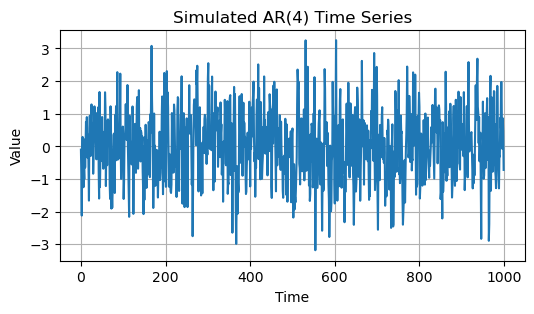

In [5]:
# Plot the simulated AR(4) process
plt.figure(figsize=(6, 3))
plt.plot(ar4_series)
plt.title("Simulated AR(4) Time Series")
plt.xlabel("Time")
plt.ylabel("Value")
plt.grid(True)
plt.show()

### (b)


The formula for the spectral density of an AR($p$) process is

$$ \frac{\sigma_{\varepsilon}^2}{\left|1 - \phi_1 e^{- i 2 \pi f} - \phi_2 e^{- i 2 \pi f 2} - \ldots - \phi_p e^{- i 2 \pi f p}\right|^2} $$

where $f$ is the frequency. 

In [6]:
def S_AR(f, phis, sigma2):
    """
    Compute the spectral density function for an AR(p) process.

    Parameters:
    f (np.ndarray): The vector of frequencies at which the spectral density should be evaluated.
    phis (np.ndarray): The vector of AR coefficients (phi_1, phi_2, ..., phi_p).
    sigma2 (float): The variance of the white noise process.

    Returns:
    np.ndarray: The spectral density function evaluated at the frequencies `f`.
    """
    
    p = len(phis)  # Order of the AR process
    spectral_density = np.zeros(len(f))

    # Compute the spectral density at each frequency
    for i, frequency in enumerate(f):
        # Compute the denominator for the spectral density formula
        denominator = 1 - sum(
            phis[k] * np.exp(-2 * np.pi * 1j * (k + 1) * frequency) for k in range(p)
        )
        # Compute the spectral density
        spectral_density[i] = sigma2 / (np.abs(denominator) ** 2)

    return spectral_density

### (c)


The formula for the periodogram of a process:

$$
\hat{S}^{(p)} (f) = \frac{1}{N} \left| \sum_{t=1}^N X_t e^{-i 2 \pi f t} \right|^2
$$

where $f$ is the frequency.

The function `np.fft.fft` returns the $\sum_{t=1}^N X_t e^{-i 2 \pi f t}$ evaluated at $f = 0, \frac{1}{N}, \frac{2}{N}, \ldots, \frac{N-1}{N}$. 

We also add the option to shift the frequencies at $0$, if requested.

In [7]:
def periodogram(x, shift=False, output_freqs=False):
    """
    Compute the periodogram at the Fourier frequencies for a time series x.

    Parameters:
    :param x (np.ndarray): Time series data.
    :param shift (bool): Whether to shift the frequencies to be centered at 0.
    :param output_freqs (bool): Whether to output the frequencies.

    Returns:
    :return (np.ndarray): Periodogram of x.
    """

    N = len(x)  # Length of the time series

    # Compute the FFT of the time series with the frequencies centered at 0
    fft = np.fft.fft(x)

    # Center the frequencies at 0, if requested
    if shift:
        fft = np.fft.fftshift(fft)

    # Compute the periodogram at the Fourier frequencies
    periodogram = np.abs(fft) ** 2 / N

    if output_freqs:
        freqs = np.fft.fftfreq(N)
        if shift:
            freqs = np.fft.fftshift(freqs)

        return periodogram, freqs

    return periodogram

In [8]:
N = 10

# Generate a time series
dummy_data = np.random.normal(size=N)

# Compute the Fourier frequencies and periodogram
_, freqs = periodogram(dummy_data, shift=True, output_freqs=True)

# Print the relevant Fourier frequencies as a vector
print("Fourier frequencies:")
print(freqs)

Fourier frequencies:
[-0.5 -0.4 -0.3 -0.2 -0.1  0.   0.1  0.2  0.3  0.4]


The $ p \times 100\% $ cosine taper is defined by

$$
h_t = 
\begin{cases}
\frac{C}{2} \left[ 1 - \cos \left( \frac{2\pi t}{ \lfloor pN \rfloor +1} \right) \right] 
&, 1 \leq t \leq \frac{\lfloor pN \rfloor}{2}; 
\\
C 
&, \frac{\lfloor pN \rfloor}{2} < t < N + 1 - \frac{\lfloor pN \rfloor}{2}; 
\\
\frac{C}{2} \left[ 1 - \cos \left( \frac{2\pi (N+1-t)}{\lfloor pN \rfloor+1} \right) \right] 
&, N + 1 - \frac{\lfloor pN \rfloor}{2} \leq t \leq N,
\end{cases}
$$

where $C$ is a normalizing constant that forces $\sum_{t=1}^{N} h_t^2 = 1$.

The direct spectral estimator is defined by

$$
\hat{S}^{(d)} (f) = \frac{1}{N} \left| \sum_{t=1}^N h_t X_t e^{-i 2 \pi f t} \right|^2
$$


In [9]:
def cosine_taper(X, p):
    """
    Generate a p x 100% cosine taper function based on the provided parameters.

    Parameters:
    :param X (np.ndarray): The time series data.
    :param p (float): The percentage of the time series to taper.

    Returns:
    np.ndarray: The cosine taper function
    """

    # Length of the time series
    N = len(X)
    # Number of points to taper
    num_taper = int(np.floor(p * N))

    # Create the taper window
    taper = np.ones(N)
    for t in range(0, num_taper // 2):
        taper[t] = (1 - np.cos(2 * np.pi * t / (num_taper + 1))) / 2
        taper[-t - 1] = (1 - np.cos(2 * np.pi * (t + 1) / (num_taper + 1))) / 2

    # Normalize the taper
    C = 1 / np.sqrt(np.sum(taper**2))
    taper *= C

    return taper

In [10]:
def direct(X, p, shift=False):
    """
    Compute the direct spectral estimate of the time series X.

    Parameters:
    :param X (np.ndarray): The time series data.
    :param p (float): The percentage of the time series to taper.
    :param shift (bool): Whether to shift the frequencies to be centered at 0.

    Returns:
    scalar: The direct spectral estimate.
    """

    # Compute the cosine taper
    taper = cosine_taper(X, p)

    # Compute the tapered time series
    X_tapered = X * taper

    # Compute the FFT of the tapped time series
    fft = np.fft.fft(X_tapered)

    # If requested, center the frequencies at 0
    if shift:
        fft = np.fft.fftshift(fft)

    # Compute the direct spectral estimate
    estimator = np.abs(fft) ** 2

    return estimator

### (d)


In [11]:
num_realizations = 5000

# Parameters for the AR(4) process
N = 64
sigma_e = 1
f1 = 6 / 64
f2 = 26 / 64

# Parameters for cosine taper
tapers = [0.05, 0.1, 0.35, 0.5]

# Parameters for periodogram
freq_indexes = np.array([6, 8, 16, 26])
frequencies = freq_indexes / N

#### (A)


In [12]:
def compute_periodogram_and_direct_values(r):
    """
    Compute the periodogram and direct spectral estimate values for the given radius r.
    """

    # Store the periodogram values
    periodogram_values = np.zeros((num_realizations, len(freq_indexes)))
    # Store the direct spectral estimate values
    direct_values = np.zeros((num_realizations, len(tapers), len(freq_indexes)))

    # Simulation loop
    for realization in range(num_realizations):
        x = simulate_ar4(N, sigma_e, f1, f2, r, r)

        for i, taper in enumerate(tapers):
            # Compute the periodogram and store it.
            periodogram_values[realization] = periodogram(x)[freq_indexes]

            # Compute the direct spectral estimate and store it.
            direct_values[realization, i] = direct(x, taper)[freq_indexes]

    return periodogram_values, direct_values

In [13]:
# Parameters for the AR(4) process
r = 0.8

# Compute the periodogram and direct spectral estimate values for the given radius r.
periodogram_values, direct_values = compute_periodogram_and_direct_values(r)

#### (B)

In [14]:
def compute_percentage_bias(estimates, true_values):
    """
    Compute the percentage bias for the given estimates.
    """

    # Compute the mean of the estimates
    mean = np.mean(estimates, axis=0)

    # Compute the percentage bias
    percentage_bias = 100 * (mean - true_values) / true_values

    return percentage_bias

In [15]:
# Compute the spectral density function for the AR(4) process
spectral_values = S_AR(frequencies, compute_ar4_coeffs(f1, f2, r, r), sigma_e)

# Compute the sample percentage bias of the periodogram
periodogram_bias = compute_percentage_bias(periodogram_values, spectral_values)

# Compute the sample percentage bias of the direct spectral estimate
direct_bias = compute_percentage_bias(direct_values, spectral_values)

print(periodogram_bias)
print(direct_bias)

[-6.54526601  2.07231189 11.37964559 -8.62335382]
[[-6.73083273  2.20538461  9.85366356 -8.72496199]
 [-6.55577015  2.17609473  6.1429273  -8.2913768 ]
 [-5.25381267  2.74399543  1.24379097 -7.21048147]
 [-4.52028887  2.90977708  0.67523483 -6.75200272]]


#### (C)

In [16]:
r_range = np.arange(0.81, 1.00, 0.01)

# Store the periodogram and direct spectral estimate biases
periodogram_biases = np.zeros((len(r_range), len(freq_indexes)))
direct_biases = np.zeros((len(r_range), len(tapers), len(freq_indexes)))

for i, r in enumerate(r_range):
    # Compute the periodogram and direct spectral estimate values for the given radius r.
    periodogram_values, direct_values = compute_periodogram_and_direct_values(r)

    # Compute the spectral density function for the AR(4) process
    spectral_values = S_AR(frequencies, compute_ar4_coeffs(f1, f2, r, r), sigma_e)

    # Compute the sample percentage bias of the periodogram and store it
    periodogram_biases[i] = compute_percentage_bias(periodogram_values, spectral_values)

    # Compute the sample percentage bias of the direct spectral estimate
    direct_biases[i] = compute_percentage_bias(direct_values, spectral_values)

#### (D)

We make four plots, one for each frequency, that compare the periodogram and the direct spectral estimators for different values of $p$, as a function $r$.

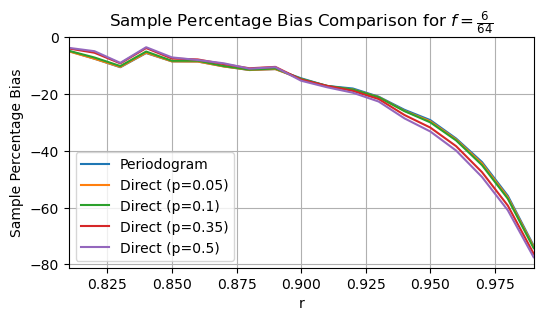

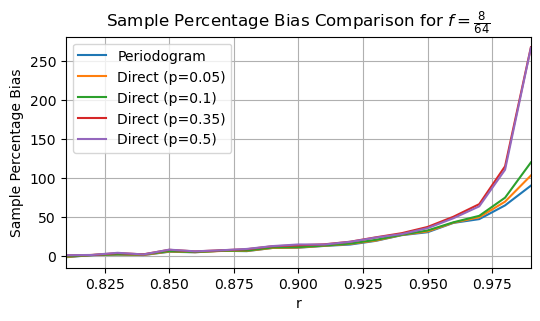

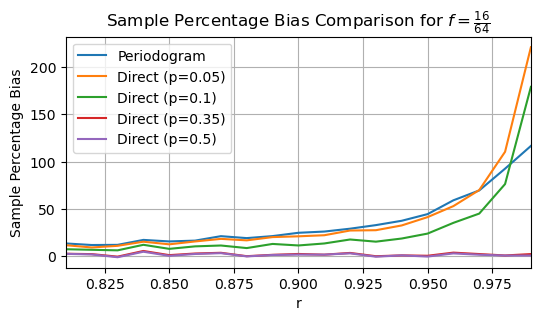

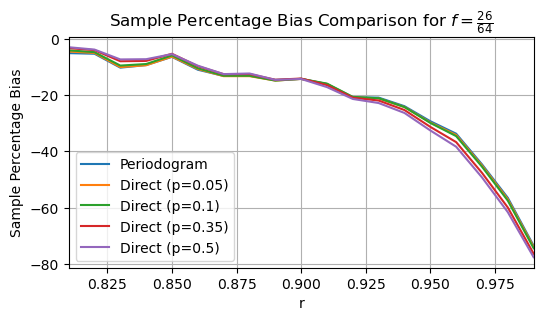

In [17]:
# Plot the biases for each frequency
for i, freq in enumerate(freq_indexes):
    plt.figure(figsize=(6, 3))

    plt.plot(r_range, periodogram_biases[:, i], label="Periodogram")
    for j, taper in enumerate(tapers):
        plt.plot(r_range, direct_biases[:, j, i], label=f"Direct (p={taper})")

    plt.xlim(r_range[0], r_range[-1])
    plt.xlabel("r")
    plt.ylabel("Sample Percentage Bias")

    plt.title(rf"Sample Percentage Bias Comparison for $f = \frac{{{freq}}}{{{N}}}$")
    plt.legend()
    plt.grid(True)
    plt.show()

#### (E)

We know that for $r < 1$ in our case we will have stationarity and for $r \geq 1$ we will not.  

As $r$ approaches $1$, there's a noticeable increase in bias percentages across all plots, because we approach non-stationarity. The periodogram exhibits lower absolute bias, as it lacks an additional taper (which would affect the bias).

Notice that for the oscillating frequencies $\frac{6}{64}$ and $\frac{26}{64}$ the bias is negative because the taper reduces the intensity of the peak, so estimate - actual < 0.

## Question 2

In [18]:
# Load the data from the .xlsx file
data = np.array(pd.read_excel("data.xlsx", header=None))

# Extract the sea level data
sea_level = data[:, 1]

# Center the sea level data
sea_level_mean = np.mean(sea_level)
sea_level -= sea_level_mean

print(sea_level.shape)
print("Mean of sea level data:", np.mean(sea_level))

(120,)
Mean of sea level data: -2.4253192047278086e-13


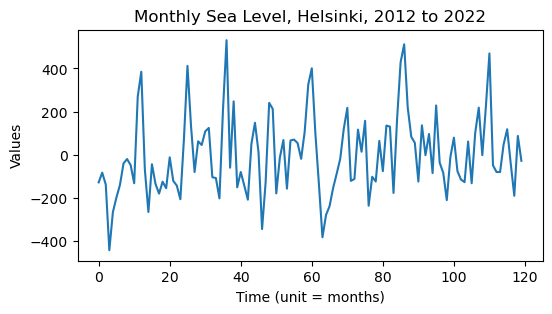

In [19]:
# Plot the time series.
plt.figure(figsize=(6, 3))
plt.title("Monthly Sea Level, Helsinki, 2012 to 2022")
plt.xlabel('Time (unit = months)')
plt.ylabel("Values")

plt.plot(sea_level)

plt.show()

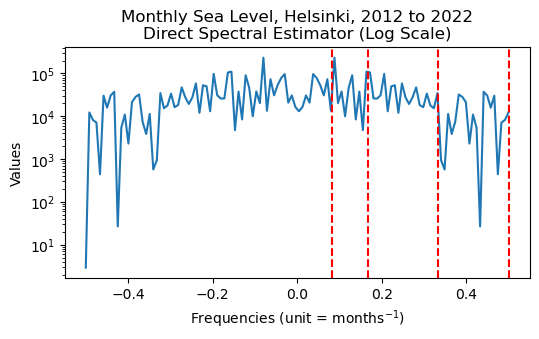

In [20]:
# Do the direct spectral estimator with a cosine taper (p = 0.25)
direct_values = direct(sea_level, 0.25, shift=True)

# Plot the direct spectral estimator
plt.figure(figsize=(6, 3))
plt.title("Monthly Sea Level, Helsinki, 2012 to 2022\nDirect Spectral Estimator (Log Scale)")
plt.xlabel(r'Frequencies (unit = months$^{-1}$)')
plt.ylabel("Values")
plt.yscale("log")

plt.plot(np.linspace(-1/2, 1/2, len(direct_values)), direct_values)

plt.axvline(x=1/12, color="red", linestyle="--")
plt.axvline(x=2/12, color="red", linestyle="--")
plt.axvline(x=4/12, color="red", linestyle="--")
plt.axvline(x=6/12, color="red", linestyle="--")

plt.show()

<u>**Data**</u>

The data is taken from [https://psmsl.org/data/obtaining/](https://psmsl.org/data/obtaining/), having records of the monthly sea level data for Helsinki, Finland, from 2012 to 2022.

<u>**Centering the data**</u>

By looking at Section 4.2.1 of the lecture notes, we see that we make the assumption that we have a zero mean process in order to have the expression of the Direct Spectral Estimator that is given in the notes.    
Therefore, in order to use the stated result, we need to center the data.

<u>**Observations**</u>

- **Annual Cycle:** The peak at $x = 1/12$ cycles per month represents an annual frequency. This suggests a strong yearly periodicity in the sea level data, where a complete cycle of increase and decrease happens over the course of a year. Such a pattern is expected due to seasonal effects like thermal expansion of water during warmer months and the melting of polar ice.
- **Semi-Annual Cycle:** The peak at $x = 2/12$ cycles per month represents a semi-annual frequency. This could be related to biannual climatic patterns, such as monsoons or semi-annual shifts in ocean currents, which can cause sea levels to rise or fall twice within a year.
- **Quarterly Cycle:** The peak at $x = 4/12$ cycles per month represents a quarterly frequency. This could be associated with more rapid seasonal changes or quarterly climatic events that affect sea levels, like shifts in regional weather patterns, such as change in temperature, precipitation, and melting or freezing of ice. For example, in some regions, sea level may be lower during colder months when more water is stored as ice in polar regions.
- **Bi-Monthly Cycle:** The peak at $x = 6/12$ cycles per month represents a bi-monthly frequency. This is very close to the $3$-months dominant frequency, so it is likely that it is also caused by seasonal changes.

## Question 3

In [21]:
# Load the data from the .xlsx file
excel_data = np.array(pd.read_excel("data.xlsx", header=None))

# Extract the sea level data
sea_level = excel_data[:, 1]

# Center the sea level data
sea_level_mean = np.mean(sea_level)
sea_level -= sea_level_mean

print(sea_level.shape)
print("Mean of sea level data:", np.mean(sea_level))

(120,)
Mean of sea level data: -2.4253192047278086e-13


### (a)

In [22]:
def rmse(errors):
    """
    Compute the root mean squared error (RMSE) for the given errors.
    """

    return np.sqrt(np.mean(np.square(errors)))

For the Yule Walker estimator, we have the following formula:

$$
\begin{aligned}
\hat{\phi}_p &= \hat{\Gamma}_p^{-1} \hat{\gamma}_p
\\
\hat{\sigma}_{\epsilon}^2 &= \hat{s}_0 - \sum_{j = 1}^p \hat{\phi}_{j, p} \hat{s_j} \\
\end{aligned}
$$

where

$$
\hat{s}_{\tau} = \frac{1}{N} \sum_{t=1}^{N - |\tau|} X_t X_{t + |\tau|}
\; \text{,} \;
\hat{\Gamma}_p = \begin{bmatrix}
\hat{s}_0 & \hat{s}_1 & \cdots & \hat{s}_{p-1} \\
\hat{s}_1 & \hat{s}_0 & \cdots & \hat{s}_{p-2} \\
\vdots & \vdots & \ddots & \vdots \\
\hat{s}_{p-1} & \hat{s}_{p-2} & \cdots & \hat{s}_0
\end{bmatrix}
\; \text{,} \;
\hat{\gamma}_p = \begin{bmatrix}
\hat{s}_1 \\
\hat{s}_2 \\
\vdots \\
\hat{s}_p
\end{bmatrix}
$$


In [23]:
def yule_walker_arp(data, p):
    """
    Compute the Yule-Walker coefficients for an AR(p) process.

    Parameters:
    :param data (np.ndarray): The time series data.
    :param p (int): The order of the AR process.

    Returns:
    :return (np.ndarray, float): The Yule-Walker coefficients and noise variance.
    """

    N = len(data)
    s = np.zeros((p + 1))

    for tau in range(p + 1):
        s[tau] = sum([data[t] * data[t + tau] for t in range(N - tau)]) / N

    # Solve the Yule-Walker equations
    coeffs = solve_toeplitz(s[:p], s[1:])

    # Calculate the noise variance
    noise_variance = s[0] - np.dot(coeffs, s[1:])

    return coeffs, noise_variance

For the $AR(p)$ maximum likelihood estimator, we have

$$
\begin{aligned}
\hat{\phi}_p &= (F^T F)^{-1} F^T X
\\
\hat{\sigma}_{\epsilon}^2 &= \frac{ (X - F \hat{\phi})^T (X - F \hat{\phi}) }{N - 2 p}
\end{aligned}
$$

where

$$
F = \begin{bmatrix}
X_p & X_{p-1} & \cdots & X_1 \\
X_{p+1} & X_p & \cdots & X_2 \\
\vdots & \vdots & \ddots & \vdots \\
X_{N-1} & X_{N-2} & \cdots & X_{N-p}
\end{bmatrix}
\; \text{,} \;
X = \begin{bmatrix}
X_{p+1} \\
X_{p+2} \\
\vdots \\
X_{N}
\end{bmatrix}
$$

In [24]:
def max_likelihood_arp(data, p):
    """
    Compute the maximum likelihood coefficients for an AR(p) process.

    Parameters:
    :param data (np.ndarray): The time series data.
    :param p (int): The order of the AR process.

    Returns:
    :return np.ndarray: The maximum likelihood coefficients.
    :return float: The estimated variance of the white noise process.
    """

    N = len(data)
    F = np.zeros((N - p, p))

    for i in range(N - p):
        F[i] = np.flip(data[i : i + p])

    X = data[p:]

    # Compute the maximum likelihood coefficients and the estimated variance
    coeffs = np.linalg.inv(F.T @ F) @ F.T @ X
    estimated_variance = ((X - F @ coeffs).T @ (X - F @ coeffs)) / (N - 2 * p)

    return coeffs, estimated_variance

In [25]:
def one_step_forecast_arp(data, p, fit_arp, start=60):
    """
    Fit the AR(p) model, perform a one-step forecast, increment the start index, and repeat.

    Parameters:
    :param data (np.ndarray): The time series data.
    :param p (int): The order of the AR process.
    :param fit_arp (function): The function to fit the AR(p) model.
    :param start (int): The starting index for the one-step forecast.

    Returns:
    :return np.ndarray: The one-step forecast values.
    """

    # Initialize the one-step forecast values and the errors
    errors = np.zeros(len(data) - start)

    # Perform a one-step forecast at each time step
    for index in range(start, len(data)):
        # Extract the first piece of data
        data_piece = data[:index]

        # Fit the AR(p) model
        coeffs, _ = fit_arp(data_piece, p)

        # Compute the one-step forecast using the AR(p) coefficients
        forecast = np.dot(coeffs, np.flip(data_piece[-p:]))

        # Compute the error
        errors[index - start] = forecast - data[index]

    return errors

In [26]:
def rmse_yw_arp(p_range):
    """
    Compute the RMSE for the Yule-Walker AR(p) model for the given range of p values.
    """

    # Initialize the RMSE values
    rmse_values = np.zeros(len(p_range))

    # Compute the RMSE for each p value
    for i, p in enumerate(p_range):
        # Compute the one-step forecast errors
        errors = one_step_forecast_arp(sea_level, p, yule_walker_arp)

        # Compute the RMSE
        rmse_values[i] = rmse(errors)

    return rmse_values

In [27]:
def rmse_ml_arp(p_range):
    """
    Compute the RMSE for the maximum likelihood AR(p) model for the given range of p values.
    """

    # Initialize the RMSE values
    rmse_values = np.zeros(len(p_range))

    # Compute the RMSE for each p value
    for i, p in enumerate(p_range):
        # Compute the one-step forecast errors
        errors = one_step_forecast_arp(sea_level, p, max_likelihood_arp)

        # Compute the RMSE
        rmse_values[i] = rmse(errors)

    return rmse_values

In [28]:
p_range = range(1, 11)

# Compute the RMSE for the Yule-Walker AR(p) model
rmse_yw = rmse_yw_arp(p_range)

# Compute the RMSE for the maximum likelihood AR(p) model
rmse_ml = rmse_ml_arp(p_range)

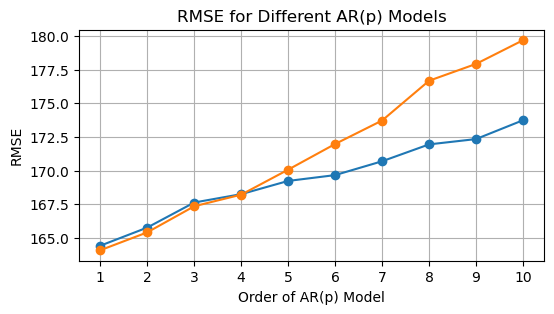

In [29]:
# Plot RMSEs for different values of p
plt.figure(figsize=(6, 3))
plt.title('RMSE for Different AR(p) Models')
plt.xlabel('Order of AR(p) Model')
plt.ylabel('RMSE')
plt.xticks(p_range)
plt.grid(True)

# Plot the RMEs for the Yule-Walker method
plt.plot(p_range, rmse_yw, marker='o', linestyle='-', label="Yule-Walker")

# Plot the RMEs for the maximum likelihood method
plt.plot(p_range, rmse_ml, marker='o', linestyle='-', label="Maximum Likelihood")

plt.show()

In [30]:
print(f"Best p for Yule-Walker Estimation: {np.argmin(rmse_yw) + 1}")
print(f"Best p for Maximum Likelihood Estimation: {np.argmin(rmse_ml) + 1}")

Best p for Yule-Walker Estimation: 1
Best p for Maximum Likelihood Estimation: 1


Based on these results, we pick the following value for $p$:

In [31]:
p = 1

### (b)

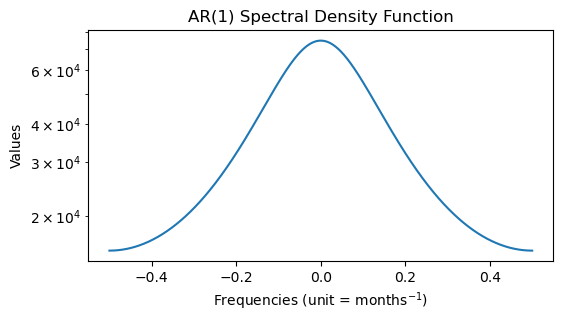

In [32]:
# Estimate the AR(p) coefficients and noise variance using
# (approximate) maximum likelihood on the entire data set
max_lik_coeffs, max_lik_noise_variance = max_likelihood_arp(sea_level, p)

# Compute the AR(p) spectral density function
frequencies = np.linspace(-1 / 2, 1 / 2, 1000)
spectral_density = S_AR(frequencies, max_lik_coeffs, max_lik_noise_variance)

# Plot the AR(p) spectral density function
plt.figure(figsize=(6, 3))
plt.title(f"AR({p}) Spectral Density Function")
plt.xlabel(r"Frequencies (unit = months$^{-1}$)")
plt.ylabel("Values")
plt.yscale("log")
plt.plot(frequencies, spectral_density)
plt.show()

### (c)

In [33]:
num_initial_months = sea_level.shape[0]

first_index_to_plot = 80
num_forecasted_months = 12


def forecast_max_lik(data, p, max_lik_coeffs, num_forecasted_months=12):
    forecast_data = data.copy()

    # Perform forecast for the next months.
    for _ in range(num_forecasted_months):
        # Compute the forecast using the AR(p) coefficients
        forecast = np.dot(max_lik_coeffs, np.flip(forecast_data[-p:]))
        # Append the forecast to the data
        forecast_data = np.append(forecast_data, forecast)

    return forecast_data[len(data) :]


forecasted_data = forecast_max_lik(
    sea_level, p, max_lik_coeffs, num_forecasted_months=num_forecasted_months
)

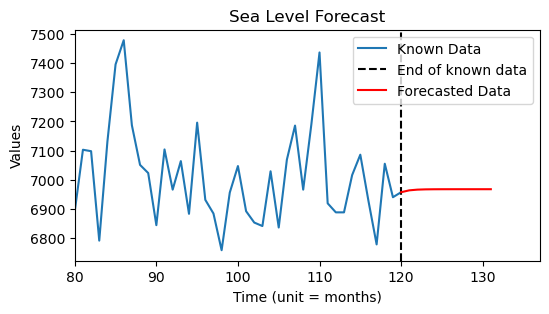

In [34]:
# Plot the forecasted sea level data,
plt.figure(figsize=(6, 3))
plt.title("Sea Level Forecast")
plt.xlabel("Time (unit = months)")
plt.ylabel("Values")

# Set the x-axis to start at first_index_to_plot
plt.xlim(first_index_to_plot, num_initial_months + num_forecasted_months + 5)


# Plot the original data
plt.plot(
    range(first_index_to_plot, num_initial_months + 1),
    np.append(sea_level[first_index_to_plot:], forecasted_data[0]) + sea_level_mean,
    label="Known Data",
)
# Plot a line to indicate the end of the original data
plt.axvline(
    x=num_initial_months, color="black", linestyle="--", label="End of known data"
)
# Plot the forecasted data
plt.plot(
    range(num_initial_months, num_initial_months + num_forecasted_months),
    forecasted_data + sea_level_mean,
    color="red",
    label="Forecasted Data",
)

plt.legend()
plt.show()

### (d)

In [35]:
def forecast_ci(forecasted_data, std_residuals):
    """
    Compute the 95% confidence interval for the forecasted data.

    Parameters:
    :param forecasted_data (np.ndarray): The forecasted data.
    :param std_residuals (float): The standard deviation of the residuals.

    Returns:
    :return (np.ndarray, np.ndarray): The upper and lower bounds of the confidence interval.
    """

    forecast_steps = np.arange(1, len(forecasted_data) + 1)

    # Naive estimator of the standard deviation of the l-step forecast distribution
    forecast_std = std_residuals * np.sqrt(forecast_steps)

    # Calculate the upper and lower bounds of the 95% prediction interval
    upper_bound = forecasted_data + 1.96 * forecast_std
    lower_bound = forecasted_data - 1.96 * forecast_std

    return upper_bound, lower_bound

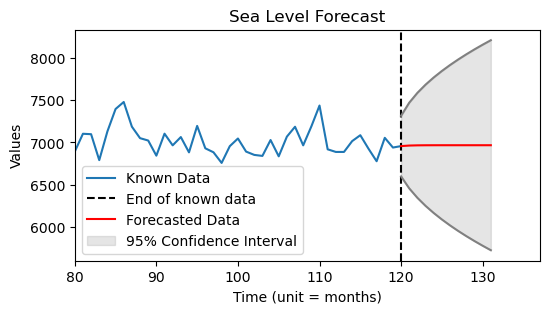

In [36]:
def plot_forecast_max_lik(p, num_forecasted_months):
    # Estimate the AR(p) coefficients and noise variance using
    # (approximate) maximum likelihood on the entire data set
    max_lik_coeffs, _ = max_likelihood_arp(sea_level, p)

    # Forecast the original sea level data
    forecasted_original_data = forecast_max_lik(
        sea_level[:p], p, max_lik_coeffs, num_forecasted_months=num_initial_months - p
    )
    # Compute the residuals
    residuals = sea_level[p:] - forecasted_original_data

    # Compute the sample standard deviation of the residuals
    sigma_e = np.std(residuals)

    # Forecast the sea level data
    forecasted_unknown_data = forecast_max_lik(
        sea_level, p, max_lik_coeffs, num_forecasted_months=num_forecasted_months
    )

    # Compute the 95% confidence interval for the residuals
    forecast_ci_upper, forecast_ci_lower = forecast_ci(forecasted_unknown_data, sigma_e)

    # Plot the forecasted sea level data
    plt.figure(figsize=(6, 3))
    plt.title("Sea Level Forecast")
    plt.xlabel("Time (unit = months)")
    plt.ylabel("Values")

    # Set the x-axis to start at first_index_to_plot
    plt.xlim(first_index_to_plot, num_initial_months + num_forecasted_months + 5)

    # Plot the original data
    plt.plot(
        range(first_index_to_plot, num_initial_months + 1),
        np.append(sea_level[first_index_to_plot:], forecasted_unknown_data[0])
        + sea_level_mean,
        label="Known Data",
    )
    # Plot a line to indicate the end of the original data
    plt.axvline(
        x=num_initial_months, color="black", linestyle="--", label="End of known data"
    )
    # Plot the forecasted data
    plt.plot(
        range(num_initial_months, num_initial_months + num_forecasted_months),
        forecasted_unknown_data + sea_level_mean,
        color="red",
        label="Forecasted Data",
    )
    # Plot the upper and lower bounds of the confidence interval
    plt.plot(
        range(num_initial_months, num_initial_months + num_forecasted_months),
        forecast_ci_upper + sea_level_mean,
        color="grey",
    )
    plt.plot(
        range(num_initial_months, num_initial_months + num_forecasted_months),
        forecast_ci_lower + sea_level_mean,
        color="grey",
    )
    # Fill the area between the upper and lower bounds
    plt.fill_between(
        range(num_initial_months, num_initial_months + num_forecasted_months),
        forecast_ci_upper + sea_level_mean,
        forecast_ci_lower + sea_level_mean,
        color="grey",
        alpha=0.2,
        label="95% Confidence Interval",
    )

    plt.legend()
    plt.show()


plot_forecast_max_lik(p, num_forecasted_months)

### (e)

We now look at a larger range for $p$ until $p = 25$. We do a plot of the residuals as above and then for different $p$ we look at the point forecasts with their corresponding confidence intervals.

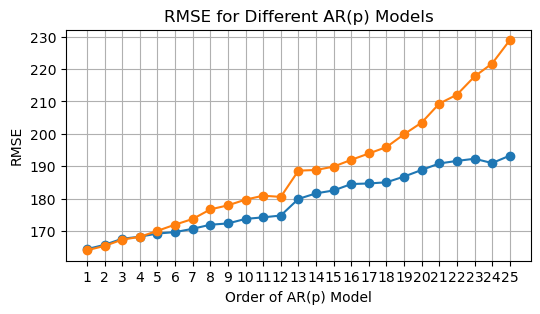

In [37]:
p_range = range(1, 26)

# Compute the RMSE for the Yule-Walker AR(p) model
rmse_yw = rmse_yw_arp(p_range)

# Compute the RMSE for the maximum likelihood AR(p) model
rmse_ml = rmse_ml_arp(p_range)

# Plot RMSEs for different values of p
plt.figure(figsize=(6, 3))
plt.title('RMSE for Different AR(p) Models')
plt.xlabel('Order of AR(p) Model')
plt.ylabel('RMSE')
plt.xticks(p_range)
plt.grid(True)

# Plot the RMEs for the Yule-Walker method
plt.plot(p_range, rmse_yw, marker='o', linestyle='-', label="Yule-Walker")

# Plot the RMEs for the maximum likelihood method
plt.plot(p_range, rmse_ml, marker='o', linestyle='-', label="Maximum Likelihood")

plt.show()

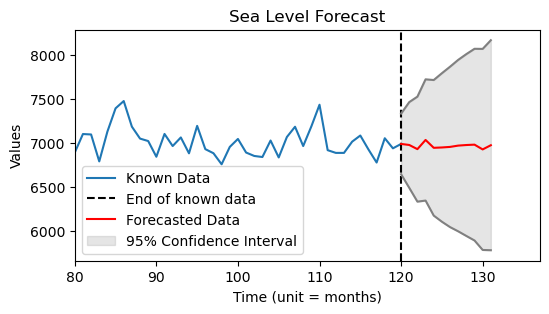

In [38]:
# For p = 15
plot_forecast_max_lik(15, num_forecasted_months)

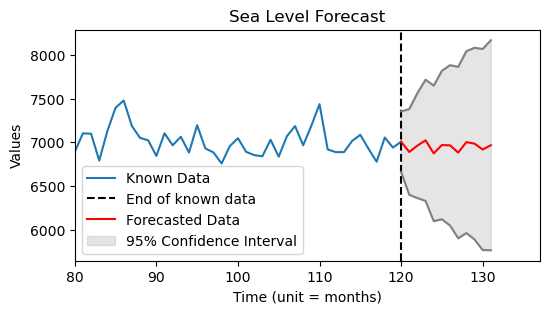

In [39]:
# For p = 20
plot_forecast_max_lik(20, num_forecasted_months)

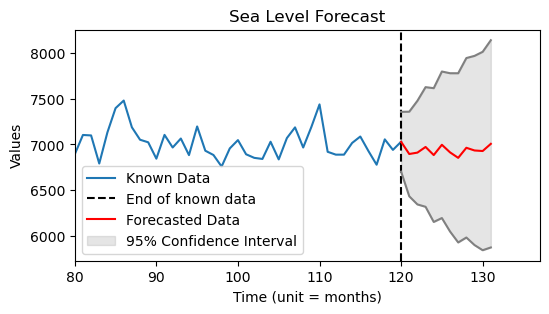

In [40]:
# For p = 25
plot_forecast_max_lik(25, num_forecasted_months)

From the residual plot, we notice a consistent increase in the RMSE using both Yule-Walker and MLE, meaning that our optimal $p$ is as before. From the different plots of the forecasts, we notice that as we increase $p$, we tend to overfit, which is also consistent with the residuals plot.    
Something like this is expected because as we increase $p$, we increase the dependency on more and more past terms in the process, which means that the model will learn the data from one point on too well. Thus, this justifies ever further our choice of $p$ from before and the given range for $p$, i.e. from $1$ to $10$.

Here are some possible explanations for why $p = 1$ might be the optimal fit:

- The data is very simple, so we don't need a complex model to fit it.
- The data doesn't have significant seasonal patterns, so the $AR(p)$ model might not be appropriate.
- The fluctuations in the data are caused by random noise rather than structural factors.

Further analysis needs to be done to determine the exact reason.